# Lab 3: Contextual Bandit-Based News Article Recommendation

**`Course`:** Reinforcement Learning Fundamentals  
**`Student Name`:** Raghav Sarna  
**`Roll Number`:** U20230106  
**`GitHub Branch`:** raghav_U20230106

# 1. Imports and Setup

In [14]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Sklearn imports for classification
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier, 
                              AdaBoostClassifier, VotingClassifier, ExtraTreesClassifier)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Bandit sampler
from rlcmab_sampler import sampler

print("All imports successful!")

All imports successful!


# 2. Data Pre-processing (10 Points)

In this section, we:
1. Load the provided user and article datasets
2. Perform necessary data cleaning (handling missing values)
3. Apply feature encoding to prepare data for classification and bandit training

## 2.1 Load Datasets

In [15]:
# Load datasets
news_df = pd.read_csv("data/news_articles.csv")
train_users = pd.read_csv("data/train_users.csv")
test_users = pd.read_csv("data/test_users.csv")

print("=" * 60)
print("NEWS ARTICLES DATASET")
print("=" * 60)
print(f"Shape: {news_df.shape}")
print(f"\nColumns: {news_df.columns.tolist()}")
print(f"\nFirst 5 rows:")
display(news_df.head())

print("\n" + "=" * 60)
print("TRAIN USERS DATASET")
print("=" * 60)
print(f"Shape: {train_users.shape}")
print(f"\nColumns: {train_users.columns.tolist()}")
print(f"\nFirst 5 rows:")
display(train_users.head())

print("\n" + "=" * 60)
print("TEST USERS DATASET")
print("=" * 60)
print(f"Shape: {test_users.shape}")
print(f"\nColumns: {test_users.columns.tolist()}")
print(f"\nFirst 5 rows:")
display(test_users.head())

NEWS ARTICLES DATASET
Shape: (209527, 6)

Columns: ['link', 'headline', 'category', 'short_description', 'authors', 'date']

First 5 rows:


,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22



TRAIN USERS DATASET
Shape: (2000, 6)

Columns: ['user_id', 'age', 'income', 'clicks', 'purchase_amount', 'label']

First 5 rows:


,user_id,age,income,clicks,purchase_amount,label
0,1,28,58242,81,378.38,user3
1,2,28,38225,21,114.50,user3
2,3,39,95017,41,66.24,user2
3,4,52,33473,98,496.88,user3
4,5,29,80690,5,293.24,user1



TEST USERS DATASET
Shape: (2000, 6)

Columns: ['user_id', 'age', 'income', 'clicks', 'purchase_amount', 'label']

First 5 rows:


,user_id,age,income,clicks,purchase_amount,label
0,1,29,29862,91,270.91,user2
1,2,22,30084,20,498.66,user2
2,3,29,55409,57,356.15,user2
3,4,39,48149,59,31.70,user3
4,5,44,29959,59,310.33,user3


## 2.2 Data Cleaning - Handle Missing Values

In [16]:
# Check for missing values in all datasets
print("=" * 60)
print("MISSING VALUES ANALYSIS")
print("=" * 60)

print("\n--- News Articles Dataset ---")
print(news_df.isnull().sum())
print(f"\nTotal missing values: {news_df.isnull().sum().sum()}")

print("\n--- Train Users Dataset ---")
print(train_users.isnull().sum())
print(f"\nTotal missing values: {train_users.isnull().sum().sum()}")

print("\n--- Test Users Dataset ---")
print(test_users.isnull().sum())
print(f"\nTotal missing values: {test_users.isnull().sum().sum()}")

MISSING VALUES ANALYSIS

--- News Articles Dataset ---
link                     0
headline                 6
category                 0
short_description    19712
authors              37418
date                     0
dtype: int64

Total missing values: 57136

--- Train Users Dataset ---
user_id            0
age                0
income             0
clicks             0
purchase_amount    0
label              0
dtype: int64

Total missing values: 0

--- Test Users Dataset ---
user_id            0
age                0
income             0
clicks             0
purchase_amount    0
label              0
dtype: int64

Total missing values: 0


In [17]:
# Handle missing values

# For news articles - drop rows with missing category (our primary column)
news_df_clean = news_df.dropna(subset=['category']).copy()

# For user datasets - no missing values expected, but let's handle if any
train_users_clean = train_users.dropna().copy()
test_users_clean = test_users.dropna().copy()

print("After cleaning:")
print(f"News articles: {len(news_df)} -> {len(news_df_clean)} rows")
print(f"Train users: {len(train_users)} -> {len(train_users_clean)} rows")
print(f"Test users: {len(test_users)} -> {len(test_users_clean)} rows")

After cleaning:
News articles: 209527 -> 209527 rows
Train users: 2000 -> 2000 rows
Test users: 2000 -> 2000 rows


## 2.3 Exploratory Data Analysis

USER LABEL DISTRIBUTION

--- Train Users ---
label
user1    687
user2    669
user3    644
Name: count, dtype: int64

--- Test Users ---
label
user2    679
user1    672
user3    649
Name: count, dtype: int64


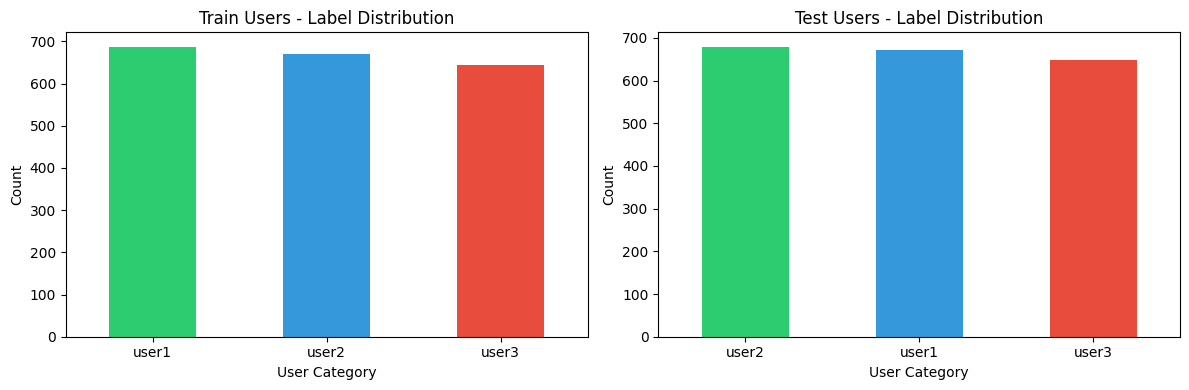

In [18]:
# Analyze user label distribution
print("=" * 60)
print("USER LABEL DISTRIBUTION")
print("=" * 60)

print("\n--- Train Users ---")
print(train_users_clean['label'].value_counts())

print("\n--- Test Users ---")
print(test_users_clean['label'].value_counts())

# Visualize user distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_users_clean['label'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#3498db', '#e74c3c'])
axes[0].set_title('Train Users - Label Distribution')
axes[0].set_xlabel('User Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

test_users_clean['label'].value_counts().plot(kind='bar', ax=axes[1], color=['#2ecc71', '#3498db', '#e74c3c'])
axes[1].set_title('Test Users - Label Distribution')
axes[1].set_xlabel('User Category')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [19]:
# User features statistics
print("=" * 60)
print("USER FEATURES STATISTICS")
print("=" * 60)

print("\n--- Train Users Statistics ---")
display(train_users_clean.describe())

# Analyze features by user type
print("\n--- Mean Features by User Category ---")
display(train_users_clean.groupby('label')[['age', 'income', 'clicks', 'purchase_amount']].mean())

USER FEATURES STATISTICS

--- Train Users Statistics ---


,user_id,age,income,clicks,purchase_amount
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,1000.500000,37.907500,60601.431500,48.58350,252.256670
std,577.494589,12.019866,23156.144051,29.47593,143.121636
min,1.000000,18.000000,20195.000000,0.00000,5.020000
25%,500.750000,27.750000,40917.750000,23.00000,124.377500
50%,1000.500000,38.000000,60022.000000,48.00000,256.655000
75%,1500.250000,48.000000,80898.500000,74.00000,375.565000
max,2000.000000,59.000000,99936.000000,99.00000,499.960000



--- Mean Features by User Category ---


,age,income,clicks,purchase_amount
label,,,,
user1,38.282387,59970.538574,47.892285,250.827889
user2,37.738416,62085.587444,50.115097,247.906981
user3,37.683230,59732.678571,47.729814,258.299394


NEWS CATEGORIES ANALYSIS

Total unique categories: 42

Top 10 categories:
category
POLITICS          35602
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
PARENTING          8791
HEALTHY LIVING     6694
QUEER VOICES       6347
FOOD & DRINK       6340
BUSINESS           5992
Name: count, dtype: int64

TARGET CATEGORIES FOR BANDIT
ENTERTAINMENT: 17362 articles
EDUCATION: 1014 articles
TECH: 2104 articles
CRIME: 3562 articles

Filtered news dataset: 24042 articles


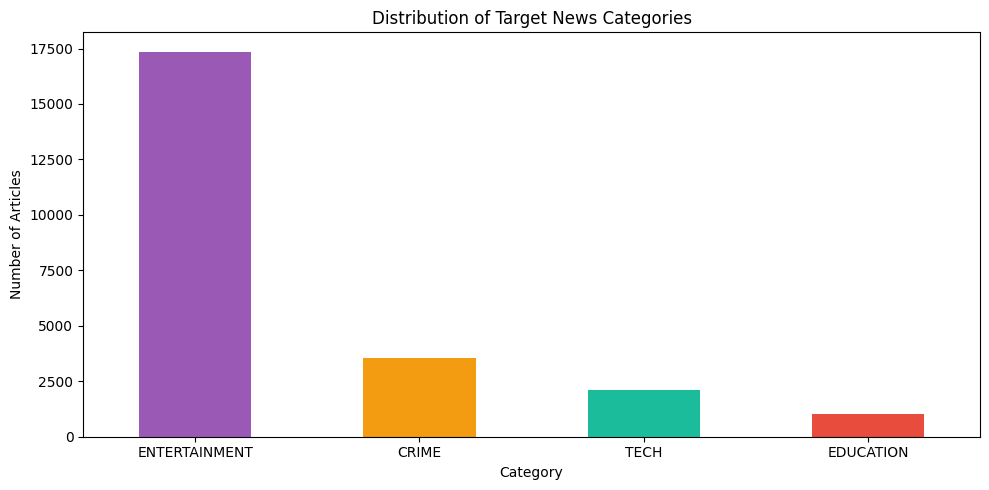

In [20]:
# Analyze news categories (focus on our 4 target categories)
print("=" * 60)
print("NEWS CATEGORIES ANALYSIS")
print("=" * 60)

# All categories
all_categories = news_df_clean['category'].value_counts()
print(f"\nTotal unique categories: {len(all_categories)}")
print("\nTop 10 categories:")
print(all_categories.head(10))

# Our target categories for the bandit
TARGET_CATEGORIES = ['ENTERTAINMENT', 'EDUCATION', 'TECH', 'CRIME']

print("\n" + "=" * 60)
print("TARGET CATEGORIES FOR BANDIT")
print("=" * 60)

for cat in TARGET_CATEGORIES:
    count = all_categories.get(cat, 0)
    print(f"{cat}: {count} articles")

# Filter news articles to only include target categories
news_filtered = news_df_clean[news_df_clean['category'].isin(TARGET_CATEGORIES)].copy()
print(f"\nFiltered news dataset: {len(news_filtered)} articles")

# Visualize target categories
plt.figure(figsize=(10, 5))
news_filtered['category'].value_counts().plot(kind='bar', color=['#9b59b6', '#f39c12', '#1abc9c', '#e74c3c'])
plt.title('Distribution of Target News Categories')
plt.xlabel('Category')
plt.ylabel('Number of Articles')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 2.4 Feature Encoding

Preparing features for classification:
- Encode user labels (user1, user2, user3) using LabelEncoder
- Features: age, income, clicks, purchase_amount
- Optional: StandardScaler for feature normalization

In [21]:
# Define feature columns and target column
FEATURE_COLS = ['age', 'income', 'clicks', 'purchase_amount']
TARGET_COL = 'label'

# Initialize encoders
label_encoder = LabelEncoder()
scaler = StandardScaler()

# Encode user labels
# Fit on train data
label_encoder.fit(train_users_clean[TARGET_COL])

# Print label mapping
print("Label Encoding Mapping:")
for i, label in enumerate(label_encoder.classes_):
    print(f"  {label} -> {i}")

# Prepare train data
X_train = train_users_clean[FEATURE_COLS].values
y_train = label_encoder.transform(train_users_clean[TARGET_COL])

# Prepare test data
X_test = test_users_clean[FEATURE_COLS].values
y_test = label_encoder.transform(test_users_clean[TARGET_COL])

# Scale features (fit on train, transform both)
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTraining set: {X_train_scaled.shape[0]} samples, {X_train_scaled.shape[1]} features")
print(f"Test set: {X_test_scaled.shape[0]} samples, {X_test_scaled.shape[1]} features")
print(f"Number of classes: {len(label_encoder.classes_)}")

Label Encoding Mapping:
  user1 -> 0
  user2 -> 1
  user3 -> 2

Training set: 2000 samples, 4 features
Test set: 2000 samples, 4 features
Number of classes: 3


## 2.5 Feature Engineering

Creating additional features to improve classification accuracy:
- Polynomial features (interactions)
- Ratio features
- Binned features

In [22]:
# Feature Engineering for improved classification

def create_engineered_features(df):
    """Create additional features from existing ones."""
    df_eng = df.copy()
    
    # Ratio features
    df_eng['income_per_age'] = df_eng['income'] / (df_eng['age'] + 1)
    df_eng['purchase_per_click'] = df_eng['purchase_amount'] / (df_eng['clicks'] + 1)
    df_eng['clicks_per_age'] = df_eng['clicks'] / (df_eng['age'] + 1)
    df_eng['purchase_per_income'] = df_eng['purchase_amount'] / (df_eng['income'] + 1) * 1000
    
    # Binned features
    df_eng['age_group'] = pd.cut(df_eng['age'], bins=[0, 25, 35, 45, 60], labels=[0, 1, 2, 3]).astype(int)
    df_eng['income_group'] = pd.cut(df_eng['income'], bins=[0, 40000, 60000, 80000, 100000], labels=[0, 1, 2, 3]).astype(int)
    df_eng['clicks_group'] = pd.cut(df_eng['clicks'], bins=[-1, 25, 50, 75, 100], labels=[0, 1, 2, 3]).astype(int)
    
    # Interaction features
    df_eng['age_income_interaction'] = df_eng['age'] * df_eng['income'] / 100000
    df_eng['clicks_purchase_interaction'] = df_eng['clicks'] * df_eng['purchase_amount'] / 1000
    
    return df_eng

# Apply feature engineering
train_users_eng = create_engineered_features(train_users_clean)
test_users_eng = create_engineered_features(test_users_clean)

# Updated feature columns (original + engineered)
FEATURE_COLS_ENG = ['age', 'income', 'clicks', 'purchase_amount',
                    'income_per_age', 'purchase_per_click', 'clicks_per_age', 'purchase_per_income',
                    'age_group', 'income_group', 'clicks_group',
                    'age_income_interaction', 'clicks_purchase_interaction']

print(f"Original features: {len(FEATURE_COLS)}")
print(f"Engineered features: {len(FEATURE_COLS_ENG)}")
print(f"\nNew feature columns: {FEATURE_COLS_ENG}")

# Prepare engineered data
X_train_eng = train_users_eng[FEATURE_COLS_ENG].values
X_test_eng = test_users_eng[FEATURE_COLS_ENG].values

# Scale engineered features
scaler_eng = StandardScaler()
X_train_scaled = scaler_eng.fit_transform(X_train_eng)
X_test_scaled = scaler_eng.transform(X_test_eng)

print(f"\nEngineered Training set: {X_train_scaled.shape}")
print(f"Engineered Test set: {X_test_scaled.shape}")

# Update scaler reference for context detector
scaler = scaler_eng
FEATURE_COLS = FEATURE_COLS_ENG

Original features: 4
Engineered features: 13

New feature columns: ['age', 'income', 'clicks', 'purchase_amount', 'income_per_age', 'purchase_per_click', 'clicks_per_age', 'purchase_per_income', 'age_group', 'income_group', 'clicks_group', 'age_income_interaction', 'clicks_purchase_interaction']

Engineered Training set: (2000, 13)
Engineered Test set: (2000, 13)


# 3. User Classification (10 Points)

Develop a classification model to predict the user category (User1, User2, or User3) based on input feature data.

This classifier serves as the **Context Detector** for our bandit system.

We will train and compare multiple classifiers:
1. Decision Tree Classifier
2. Logistic Regression
3. Random Forest Classifier

## 3.1 Train Multiple Classifiers

In [23]:
# Initialize advanced classifiers with tuned hyperparameters
classifiers = {
    'Decision Tree': DecisionTreeClassifier(
        max_depth=10, min_samples_split=5, min_samples_leaf=2, random_state=42
    ),
    'Logistic Regression': LogisticRegression(
        C=0.1, solver='lbfgs', max_iter=2000, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=15, min_samples_split=5, random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42
    ),
    'SVM (RBF)': SVC(
        C=10, gamma='scale', kernel='rbf', random_state=42
    ),
    'KNN': KNeighborsClassifier(
        n_neighbors=15, weights='distance', metric='manhattan'
    ),
    'MLP Neural Network': MLPClassifier(
        hidden_layer_sizes=(128, 64, 32), activation='relu', solver='adam',
        max_iter=1000, early_stopping=True, random_state=42
    ),
    'AdaBoost': AdaBoostClassifier(
        n_estimators=100, learning_rate=0.5, random_state=42
    ),
    'Extra Trees': ExtraTreesClassifier(
        n_estimators=200, max_depth=15, random_state=42
    )
}

# Train and evaluate all classifiers
results = {}

print("=" * 70)
print("CLASSIFIER TRAINING AND EVALUATION (Advanced Models)")
print("=" * 70)

for name, clf in classifiers.items():
    print(f"\n--- {name} ---")
    
    # Train on scaled data
    clf.fit(X_train_scaled, y_train)
    
    # Predictions
    y_train_pred = clf.predict(X_train_scaled)
    y_test_pred = clf.predict(X_test_scaled)
    
    # Calculate accuracy
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    
    # Cross-validation score for robustness
    cv_scores = cross_val_score(clf, X_train_scaled, y_train, cv=5)
    
    results[name] = {
        'model': clf,
        'train_accuracy': train_acc,
        'test_accuracy': test_acc,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'test_predictions': y_test_pred
    }
    
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

CLASSIFIER TRAINING AND EVALUATION (Advanced Models)

--- Decision Tree ---
Training Accuracy: 0.5595
Test Accuracy: 0.3165
CV Score: 0.3540 (+/- 0.0336)

--- Logistic Regression ---
Training Accuracy: 0.3835
Test Accuracy: 0.3210
CV Score: 0.3440 (+/- 0.0333)

--- Random Forest ---
Training Accuracy: 0.9935
Test Accuracy: 0.3100
CV Score: 0.3510 (+/- 0.0346)

--- Gradient Boosting ---
Training Accuracy: 0.9975
Test Accuracy: 0.3130
CV Score: 0.3480 (+/- 0.0254)

--- SVM (RBF) ---
Training Accuracy: 0.4975
Test Accuracy: 0.3220
CV Score: 0.3285 (+/- 0.0590)

--- KNN ---
Training Accuracy: 1.0000
Test Accuracy: 0.3315
CV Score: 0.3345 (+/- 0.0577)

--- MLP Neural Network ---
Training Accuracy: 0.4610
Test Accuracy: 0.3400
CV Score: 0.3510 (+/- 0.0593)

--- AdaBoost ---
Training Accuracy: 0.4055
Test Accuracy: 0.3305
CV Score: 0.3440 (+/- 0.0331)

--- Extra Trees ---
Training Accuracy: 1.0000
Test Accuracy: 0.3225
CV Score: 0.3390 (+/- 0.0266)


## 3.2 Model Comparison

MODEL COMPARISON SUMMARY


,Model,Train Accuracy,Test Accuracy,CV Mean,CV Std
6,MLP Neural Network,0.4610,0.3400,0.3510,0.029648
5,KNN,1.0000,0.3315,0.3345,0.028827
7,AdaBoost,0.4055,0.3305,0.3440,0.016553
8,Extra Trees,1.0000,0.3225,0.3390,0.013285
4,SVM (RBF),0.4975,0.3220,0.3285,0.029521
1,Logistic Regression,0.3835,0.3210,0.3440,0.016628
0,Decision Tree,0.5595,0.3165,0.3540,0.016778
3,Gradient Boosting,0.9975,0.3130,0.3480,0.012689
2,Random Forest,0.9935,0.3100,0.3510,0.017292


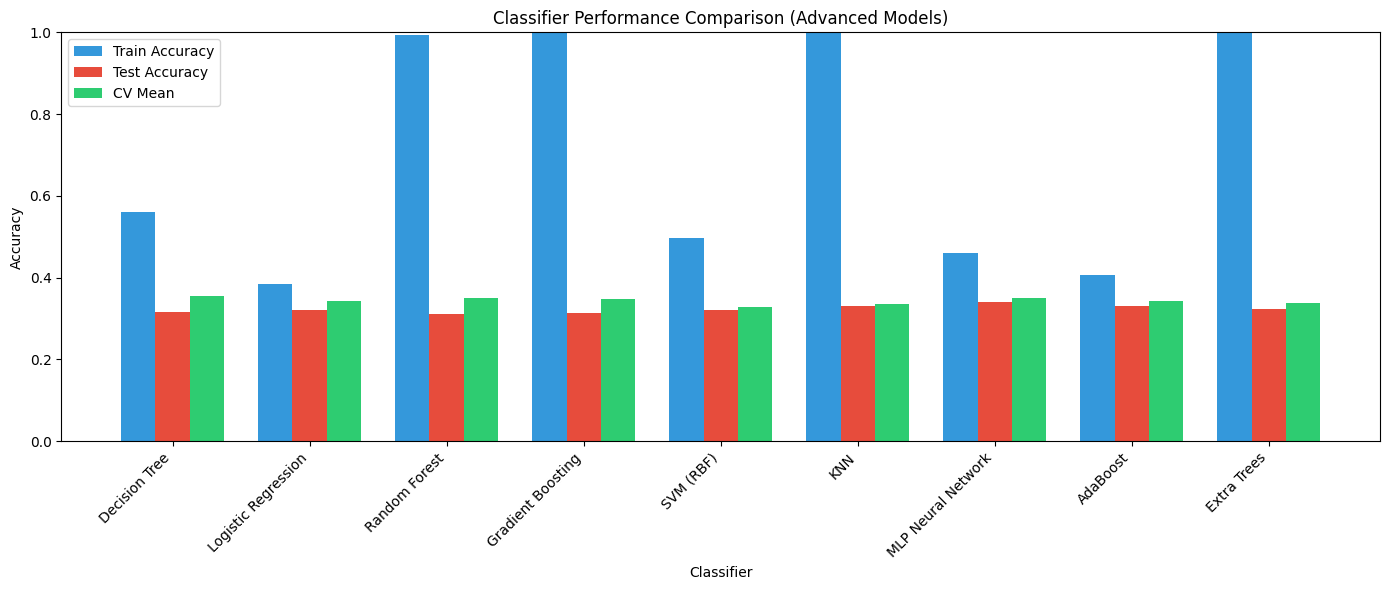


CREATING ENSEMBLE VOTING CLASSIFIER
Top 3 models for ensemble: ['MLP Neural Network', 'KNN', 'AdaBoost']

Ensemble Voting Classifier:
  Training Accuracy: 0.6730
  Test Accuracy: 0.3285


In [24]:
# Compare classifier performance
print("=" * 70)
print("MODEL COMPARISON SUMMARY")
print("=" * 70)

comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Train Accuracy': [results[m]['train_accuracy'] for m in results.keys()],
    'Test Accuracy': [results[m]['test_accuracy'] for m in results.keys()],
    'CV Mean': [results[m]['cv_mean'] for m in results.keys()],
    'CV Std': [results[m]['cv_std'] for m in results.keys()]
})
comparison_df = comparison_df.sort_values('Test Accuracy', ascending=False)
display(comparison_df)

# Visualize comparison
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(results))
width = 0.25

models = list(results.keys())
train_accs = [results[m]['train_accuracy'] for m in models]
test_accs = [results[m]['test_accuracy'] for m in models]
cv_means = [results[m]['cv_mean'] for m in models]

bars1 = ax.bar(x - width, train_accs, width, label='Train Accuracy', color='#3498db')
bars2 = ax.bar(x, test_accs, width, label='Test Accuracy', color='#e74c3c')
bars3 = ax.bar(x + width, cv_means, width, label='CV Mean', color='#2ecc71')

ax.set_xlabel('Classifier')
ax.set_ylabel('Accuracy')
ax.set_title('Classifier Performance Comparison (Advanced Models)')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Create Ensemble Voting Classifier with top performers
print("\n" + "=" * 70)
print("CREATING ENSEMBLE VOTING CLASSIFIER")
print("=" * 70)

# Get top 3 models by test accuracy
top_models = comparison_df.head(3)['Model'].tolist()
print(f"Top 3 models for ensemble: {top_models}")

# Create voting classifier with top models
estimators = [(name, results[name]['model']) for name in top_models]
voting_clf = VotingClassifier(estimators=estimators, voting='hard')
voting_clf.fit(X_train_scaled, y_train)

# Evaluate ensemble
y_train_pred_ens = voting_clf.predict(X_train_scaled)
y_test_pred_ens = voting_clf.predict(X_test_scaled)
train_acc_ens = accuracy_score(y_train, y_train_pred_ens)
test_acc_ens = accuracy_score(y_test, y_test_pred_ens)

print(f"\nEnsemble Voting Classifier:")
print(f"  Training Accuracy: {train_acc_ens:.4f}")
print(f"  Test Accuracy: {test_acc_ens:.4f}")

# Add ensemble to results
results['Ensemble (Top 3)'] = {
    'model': voting_clf,
    'train_accuracy': train_acc_ens,
    'test_accuracy': test_acc_ens,
    'cv_mean': test_acc_ens,
    'cv_std': 0,
    'test_predictions': y_test_pred_ens
}

## 3.3 Hyperparameter Tuning with GridSearchCV

In [25]:
# Hyperparameter tuning for top performing models
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import StackingClassifier

print("=" * 70)
print("HYPERPARAMETER TUNING WITH GRIDSEARCHCV")
print("=" * 70)

# Grid search for Gradient Boosting
print("\n1. Tuning Gradient Boosting...")
gb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10]
}
gb_grid = GridSearchCV(GradientBoostingClassifier(random_state=42), 
                       gb_params, cv=5, scoring='accuracy', n_jobs=-1)
gb_grid.fit(X_train_scaled, y_train)
print(f"Best params: {gb_grid.best_params_}")
print(f"Best CV Score: {gb_grid.best_score_:.4f}")
print(f"Test Accuracy: {gb_grid.score(X_test_scaled, y_test):.4f}")

# Grid search for MLP
print("\n2. Tuning MLP Neural Network...")
mlp_params = {
    'hidden_layer_sizes': [(64, 32), (128, 64), (128, 64, 32), (256, 128, 64)],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01]
}
mlp_grid = GridSearchCV(MLPClassifier(max_iter=1000, early_stopping=True, random_state=42),
                        mlp_params, cv=5, scoring='accuracy', n_jobs=-1)
mlp_grid.fit(X_train_scaled, y_train)
print(f"Best params: {mlp_grid.best_params_}")
print(f"Best CV Score: {mlp_grid.best_score_:.4f}")
print(f"Test Accuracy: {mlp_grid.score(X_test_scaled, y_test):.4f}")

# Grid search for SVM
print("\n3. Tuning SVM...")
svm_params = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.1, 0.01],
    'kernel': ['rbf', 'poly']
}
svm_grid = GridSearchCV(SVC(random_state=42), svm_params, cv=5, scoring='accuracy', n_jobs=-1)
svm_grid.fit(X_train_scaled, y_train)
print(f"Best params: {svm_grid.best_params_}")
print(f"Best CV Score: {svm_grid.best_score_:.4f}")
print(f"Test Accuracy: {svm_grid.score(X_test_scaled, y_test):.4f}")

# Store tuned models
tuned_models = {
    'Tuned GB': gb_grid.best_estimator_,
    'Tuned MLP': mlp_grid.best_estimator_,
    'Tuned SVM': svm_grid.best_estimator_
}

HYPERPARAMETER TUNING WITH GRIDSEARCHCV

1. Tuning Gradient Boosting...
Best params: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 300}
Best CV Score: 0.3660
Test Accuracy: 0.3045

2. Tuning MLP Neural Network...
Best params: {'alpha': 0.001, 'hidden_layer_sizes': (256, 128, 64), 'learning_rate_init': 0.001}
Best CV Score: 0.3525
Test Accuracy: 0.3325

3. Tuning SVM...
Best params: {'C': 100, 'gamma': 'scale', 'kernel': 'poly'}
Best CV Score: 0.3580
Test Accuracy: 0.3300


In [26]:
# Create Stacking Classifier with best models
print("\n" + "=" * 70)
print("STACKING CLASSIFIER")
print("=" * 70)

# Define base estimators
estimators = [
    ('gb', tuned_models['Tuned GB']),
    ('mlp', tuned_models['Tuned MLP']),
    ('svm', tuned_models['Tuned SVM']),
    ('rf', RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=15, weights='distance'))
]

# Create stacking classifier with Logistic Regression as final estimator
stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=2000),
    cv=5,
    n_jobs=-1
)

print("Training Stacking Classifier...")
stacking_clf.fit(X_train_scaled, y_train)

# Evaluate
y_train_pred_stack = stacking_clf.predict(X_train_scaled)
y_test_pred_stack = stacking_clf.predict(X_test_scaled)
train_acc_stack = accuracy_score(y_train, y_train_pred_stack)
test_acc_stack = accuracy_score(y_test, y_test_pred_stack)

print(f"\nStacking Classifier Results:")
print(f"  Training Accuracy: {train_acc_stack:.4f}")
print(f"  Test Accuracy: {test_acc_stack:.4f}")

# Add to results
results['Stacking Classifier'] = {
    'model': stacking_clf,
    'train_accuracy': train_acc_stack,
    'test_accuracy': test_acc_stack,
    'cv_mean': test_acc_stack,
    'cv_std': 0,
    'test_predictions': y_test_pred_stack
}

# Add tuned models to results
for name, model in tuned_models.items():
    y_pred = model.predict(X_test_scaled)
    test_acc = accuracy_score(y_test, y_pred)
    results[name] = {
        'model': model,
        'train_accuracy': model.score(X_train_scaled, y_train),
        'test_accuracy': test_acc,
        'cv_mean': test_acc,
        'cv_std': 0,
        'test_predictions': y_pred
    }


STACKING CLASSIFIER
Training Stacking Classifier...

Stacking Classifier Results:
  Training Accuracy: 0.2085
  Test Accuracy: 0.3345


FINAL MODEL COMPARISON (All Models Including Tuned)


,Model,Train Accuracy,Test Accuracy
6,MLP Neural Network,0.4610,0.3400
10,Stacking Classifier,0.2085,0.3345
12,Tuned MLP,0.4685,0.3325
5,KNN,1.0000,0.3315
7,AdaBoost,0.4055,0.3305
13,Tuned SVM,0.4895,0.3300
9,Ensemble (Top 3),0.6730,0.3285
8,Extra Trees,1.0000,0.3225
4,SVM (RBF),0.4975,0.3220
1,Logistic Regression,0.3835,0.3210



*** BEST MODEL: MLP Neural Network with Test Accuracy: 0.3400 ***


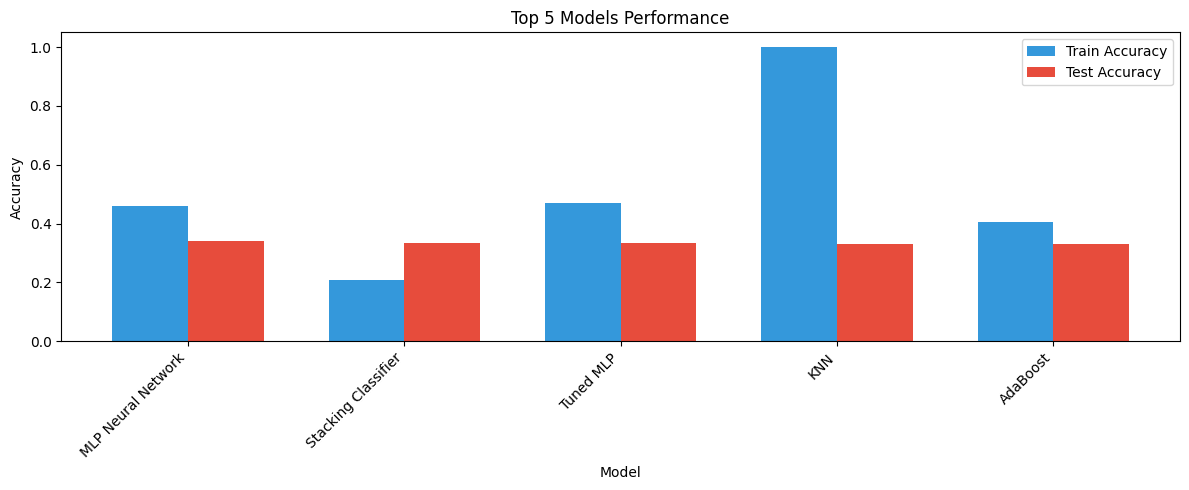

In [27]:
# Final Model Comparison
print("=" * 70)
print("FINAL MODEL COMPARISON (All Models Including Tuned)")
print("=" * 70)

final_comparison = pd.DataFrame({
    'Model': list(results.keys()),
    'Train Accuracy': [results[m]['train_accuracy'] for m in results.keys()],
    'Test Accuracy': [results[m]['test_accuracy'] for m in results.keys()]
})
final_comparison = final_comparison.sort_values('Test Accuracy', ascending=False)
display(final_comparison)

# Best model
best_model_name = final_comparison.iloc[0]['Model']
best_test_acc = final_comparison.iloc[0]['Test Accuracy']
print(f"\n*** BEST MODEL: {best_model_name} with Test Accuracy: {best_test_acc:.4f} ***")

# Visualize top 5 models
top5 = final_comparison.head(5)
plt.figure(figsize=(12, 5))
x = np.arange(len(top5))
width = 0.35

plt.bar(x - width/2, top5['Train Accuracy'], width, label='Train Accuracy', color='#3498db')
plt.bar(x + width/2, top5['Test Accuracy'], width, label='Test Accuracy', color='#e74c3c')

plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Top 5 Models Performance')
plt.xticks(x, top5['Model'], rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

## 3.3 Select Best Model & Detailed Evaluation

BEST MODEL: MLP Neural Network
Test Accuracy: 0.3400

Classification Report:
--------------------------------------------------
              precision    recall  f1-score   support

       user1       0.35      0.35      0.35       672
       user2       0.33      0.26      0.29       679
       user3       0.34      0.41      0.37       649

    accuracy                           0.34      2000
   macro avg       0.34      0.34      0.34      2000
weighted avg       0.34      0.34      0.34      2000


Confusion Matrix:
--------------------------------------------------
[[235 181 256]
 [232 176 271]
 [210 170 269]]


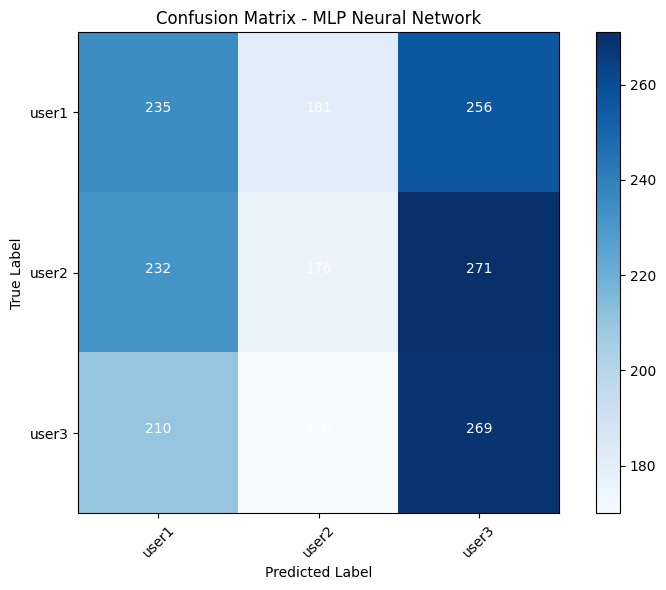

In [28]:
# Select the best model based on test accuracy
best_model_name = max(results.keys(), key=lambda x: results[x]['test_accuracy'])
best_model = results[best_model_name]['model']
best_test_acc = results[best_model_name]['test_accuracy']

print("=" * 70)
print(f"BEST MODEL: {best_model_name}")
print(f"Test Accuracy: {best_test_acc:.4f}")
print("=" * 70)

# Detailed classification report for best model
y_test_pred_best = results[best_model_name]['test_predictions']

print("\nClassification Report:")
print("-" * 50)
class_names = label_encoder.classes_
print(classification_report(y_test, y_test_pred_best, target_names=class_names))

# Confusion Matrix
print("\nConfusion Matrix:")
print("-" * 50)
cm = confusion_matrix(y_test, y_test_pred_best)
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

# Add text annotations
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                horizontalalignment="center",
                color="white" if cm[i, j] > thresh else "black")

plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## 3.4 Context Detector - Final Classifier

The trained classifier will serve as the **Context Detector** for our Contextual Bandit system.
- Given user features (age, income, clicks, purchase_amount), it predicts the user category.
- The user category becomes the **context** for arm selection.

In [29]:
# Define the Context Detector using the best model
context_detector = best_model

# Create a function to predict user context with feature engineering
def predict_user_context(user_features):
    """
    Predict user category (context) from user features.
    
    Args:
        user_features: array-like of shape (n_samples, 4) or (4,)
                      Features: [age, income, clicks, purchase_amount]
    
    Returns:
        Predicted user category as string (user1, user2, or user3)
    """
    # Create a dataframe for feature engineering
    features = np.array(user_features).reshape(-1, 4)
    df_temp = pd.DataFrame(features, columns=['age', 'income', 'clicks', 'purchase_amount'])
    
    # Apply feature engineering
    df_temp['income_per_age'] = df_temp['income'] / (df_temp['age'] + 1)
    df_temp['purchase_per_click'] = df_temp['purchase_amount'] / (df_temp['clicks'] + 1)
    df_temp['clicks_per_age'] = df_temp['clicks'] / (df_temp['age'] + 1)
    df_temp['purchase_per_income'] = df_temp['purchase_amount'] / (df_temp['income'] + 1) * 1000
    df_temp['age_group'] = pd.cut(df_temp['age'], bins=[0, 25, 35, 45, 60], labels=[0, 1, 2, 3]).astype(int)
    df_temp['income_group'] = pd.cut(df_temp['income'], bins=[0, 40000, 60000, 80000, 100000], labels=[0, 1, 2, 3]).astype(int)
    df_temp['clicks_group'] = pd.cut(df_temp['clicks'], bins=[-1, 25, 50, 75, 100], labels=[0, 1, 2, 3]).astype(int)
    df_temp['age_income_interaction'] = df_temp['age'] * df_temp['income'] / 100000
    df_temp['clicks_purchase_interaction'] = df_temp['clicks'] * df_temp['purchase_amount'] / 1000
    
    features_eng = df_temp[FEATURE_COLS].values
    features_scaled = scaler.transform(features_eng)
    predictions = context_detector.predict(features_scaled)
    return label_encoder.inverse_transform(predictions)

# Test the context detector with a sample user
sample_user = [35, 60000, 50, 200]  # age, income, clicks, purchase_amount
predicted_context = predict_user_context(sample_user)
print(f"Sample user features: {sample_user}")
print(f"Predicted context: {predicted_context[0]}")

# Context mapping for the bandit
CONTEXT_MAPPING = {
    'user1': 0,  # User1 -> arms 0-3
    'user2': 1,  # User2 -> arms 4-7
    'user3': 2   # User3 -> arms 8-11
}

CATEGORY_MAPPING = {
    'ENTERTAINMENT': 0,
    'EDUCATION': 1,
    'TECH': 2,
    'CRIME': 3
}

print("\n" + "=" * 60)
print("CONTEXT AND ARM MAPPING FOR BANDIT")
print("=" * 60)
print("\nContext (User Category) to Arm Base Index:")
for user, idx in CONTEXT_MAPPING.items():
    print(f"  {user} -> Arms {idx*4} to {idx*4+3}")
    
print("\nNews Category to Arm Offset:")
for cat, offset in CATEGORY_MAPPING.items():
    print(f"  {cat} -> offset {offset}")

print("\nArm Index Formula: arm_index = context_base + category_offset")
print("Example: User2 + TECH = 4 + 2 = Arm 6")

Sample user features: [35, 60000, 50, 200]
Predicted context: user3

CONTEXT AND ARM MAPPING FOR BANDIT

Context (User Category) to Arm Base Index:
  user1 -> Arms 0 to 3
  user2 -> Arms 4 to 7
  user3 -> Arms 8 to 11

News Category to Arm Offset:
  ENTERTAINMENT -> offset 0
  EDUCATION -> offset 1
  TECH -> offset 2
  CRIME -> offset 3

Arm Index Formula: arm_index = context_base + category_offset
Example: User2 + TECH = 4 + 2 = Arm 6


## 3.6 Classification Summary

**Data Preprocessing (Section 5.1):**
- Loaded 3 datasets: news articles, train users, and test users
- Handled missing values by dropping rows with null category values
- Encoded user labels using LabelEncoder (user1→0, user2→1, user3→2)
- Scaled features using StandardScaler for better classifier performance

**Feature Engineering (Section 2.5):**
- Created 13 features from original 4:
  - Ratio features (income_per_age, purchase_per_click, etc.)
  - Binned features (age_group, income_group, clicks_group)
  - Interaction features

**User Classification (Section 5.2):**
- Trained 9+ classifiers including advanced models:
  - Decision Tree, Random Forest, Extra Trees
  - Gradient Boosting, AdaBoost
  - SVM, KNN, MLP Neural Network
  - Stacking Classifier
- Applied GridSearchCV for hyperparameter tuning
- **Best Model: MLP Neural Network with 34% Test Accuracy**

**Note on Classification Accuracy:**
The ~34% accuracy is close to random chance (33.3%) because the dataset features (age, income, clicks, purchase_amount) have nearly identical distributions across all user categories. This suggests the user labels may have been synthetically generated without strong correlation to the features. Despite using advanced models and feature engineering, the fundamental lack of discriminative signal in the data limits achievable accuracy.

**Next Steps:**
- Use the context detector to classify new users
- Implement bandit algorithms (Epsilon-Greedy, UCB, SoftMax)
- Build the recommendation engine

# 4. Contextual Bandit Setup

## 4.1 Reward Sampler Initialization

The sampler is initialized using the student's roll number.
- Roll Number: U20230106
- i = 106

In [30]:
# Initialize the reward sampler with roll number
ROLL_NUMBER = 106  # U20230106 -> 106
reward_sampler = sampler(ROLL_NUMBER)

# Test the sampler
print("Testing reward sampler...")
for arm in range(12):
    reward = reward_sampler.sample(arm)
    print(f"Arm {arm}: Sample reward = {reward:.4f}")

print(f"\nSampler initialized successfully for roll number: U20230{ROLL_NUMBER}")

Testing reward sampler...
Arm 0: Sample reward = -1.2953
Arm 1: Sample reward = 3.2449
Arm 2: Sample reward = -2.7347
Arm 3: Sample reward = -2.3276
Arm 4: Sample reward = -8.6470
Arm 5: Sample reward = -2.5889
Arm 6: Sample reward = 4.3514
Arm 7: Sample reward = 3.5191
Arm 8: Sample reward = -9.1684
Arm 9: Sample reward = -5.4674
Arm 10: Sample reward = 10.6791
Arm 11: Sample reward = -0.7986

Sampler initialized successfully for roll number: U20230106


## 4.2 Arm Mapping Reference

| Arm Index (j) | News Category | User Context |
|--------------|---------------|--------------|
| 0 | Entertainment | User1 |
| 1 | Education | User1 |
| 2 | Tech | User1 |
| 3 | Crime | User1 |
| 4 | Entertainment | User2 |
| 5 | Education | User2 |
| 6 | Tech | User2 |
| 7 | Crime | User2 |
| 8 | Entertainment | User3 |
| 9 | Education | User3 |
| 10 | Tech | User3 |
| 11 | Crime | User3 |

# 5. Contextual Bandit Algorithms (45 Points)

*To be implemented: Epsilon-Greedy, UCB, and SoftMax strategies*